# lab1: 회로 생성과 실행

**학습 목표**
1. QNode로 양자 회로를 만들고 텍스트/그림으로 시각화한다.
2. 해석적(analytic) 결과와 유한 shots 측정 결과의 차이를 이해한다.
3. 통계 오차가 shots 수 N에 대해 1/√N 로 줄어드는 것을 직접 확인한다.

> 예제 회로: `RX(θ)|0⟩` 측정 후 `⟨Z⟩ = cos θ`. 이론값을 아는 회로라
> "왜 이 값이 나오는지"를 스스로 검증할 수 있다.

In [1]:
#!pip install -q pennylane
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt

In [2]:
theta = np.pi / 3              # 회전각 (cos(pi/3) = 0.5)
theory = float(np.cos(theta))  # 이론값 (해석적 정답)

print(f"\ntheta   : {theta:.6f}")
print(f" cos(θ) : {theory:.6f}")


theta   : 1.047198
 cos(θ) : 0.500000


In [3]:
SEED = 1234                    # 재현성: shot 샘플링 난수를 고정

dev = qml.device("default.qubit", wires=1, seed=SEED)

In [4]:
# ===========================================================
#  1-1: 기본 회로 생성 & 시각화
# ===========================================================


@qml.qnode(dev)
def circuit(angle):
    qml.RX(angle, wires=0)
    return qml.expval(qml.PauliZ(0))

print("\n[텍스트 회로도]")
print(qml.draw(circuit, decimals=3)(theta))


[텍스트 회로도]
0: ──RX(1.047)─┤  <Z>


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_29708\1293713016.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


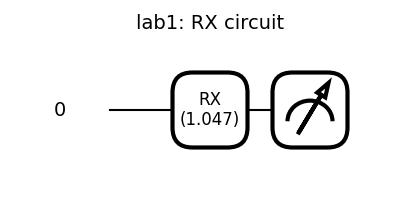

In [5]:
# matplotlib 회로도
fig, ax = qml.draw_mpl(circuit, decimals=3, style="black_white")(theta)

fig.suptitle("lab1: RX circuit", fontsize=14)
plt.tight_layout()

plt.show()

In [6]:
# 해석적 실행 (노이즈/샘플링 없는 정확한 값)
result = float(circuit(theta))
print(f"\n해석적 결과   : {result:.6f}")
print(f"이론값 cos(θ) : {theory:.6f}")
print(f"오차          : {abs(result - theory):.2e}")


해석적 결과   : 0.500000
이론값 cos(θ) : 0.500000
오차          : 1.11e-16


In [9]:
# ===========================================================
#  1-2: Shots vs Analytic
# ===========================================================


shot_counts = [32, 64, 128]
results_by_shots = {}

# 최신 API: qml.set_shots(qnode, shots=s) 로 측정 횟수를 지정한다.
for s in shot_counts:
    shot_circuit = qml.set_shots(circuit, shots=s)
    val = float(shot_circuit(theta))
    results_by_shots[s] = val
    print(f"  shots={s:>5d}  ->  <Z> = {val:+.6f}  (오차 {abs(val - theory):.4f})")

  shots=   32  ->  <Z> = +0.562500  (오차 0.0625)
  shots=   64  ->  <Z> = +0.562500  (오차 0.0625)
  shots=  128  ->  <Z> = +0.484375  (오차 0.0156)


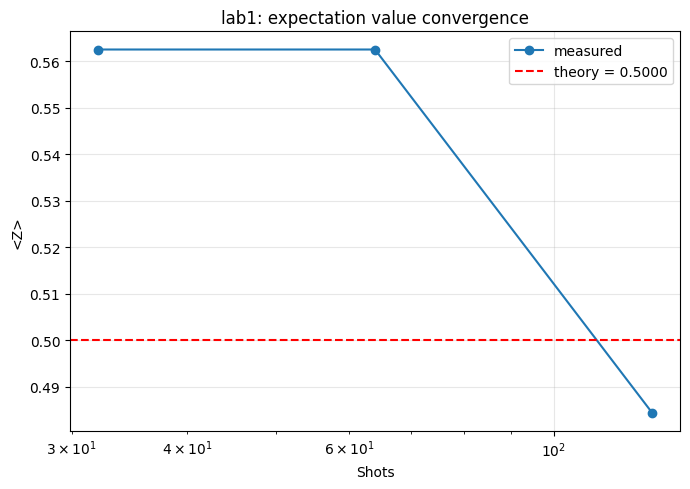

In [10]:
# 기댓값 수렴 그림
fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(list(results_by_shots.keys()),
            list(results_by_shots.values()), "o-", label="measured")
ax.axhline(y=theory, color="r", ls="--", label=f"theory = {theory:.4f}")
ax.set_xlabel("Shots")
ax.set_ylabel("<Z>")
ax.set_title("lab1: expectation value convergence")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# ===========================================================
#  1-3: 통계 오차의 1/sqrt(N) 스케일링  (log-log)
# ===========================================================
print("\n" + "=" * 60)
print("lab1-3: 오차 스케일링 1/sqrt(N)")
print("=" * 60)

# 넓은 범위 + 각 shots마다 R회 반복해 |오차| 평균 -> 경향이 선명해진다.
shot_scan = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
Repeat = 100


lab1-3: 오차 스케일링 1/sqrt(N)


In [12]:
mean_err = []
for s in shot_scan:
    errs = [abs(float(qml.set_shots(circuit, shots=s)(theta)) - theory)
            for _ in range(Repeat)]
    m = np.mean(errs)
    mean_err.append(m)
    print(f"  shots={s:>6d}  ->  mean|error| = {m:.5f}")

  shots=    32  ->  mean|error| = 0.11875
  shots=    64  ->  mean|error| = 0.08656
  shots=   128  ->  mean|error| = 0.05844
  shots=   256  ->  mean|error| = 0.04609
  shots=   512  ->  mean|error| = 0.02914
  shots=  1024  ->  mean|error| = 0.02295
  shots=  2048  ->  mean|error| = 0.01615
  shots=  4096  ->  mean|error| = 0.00976
  shots=  8192  ->  mean|error| = 0.00804
  shots= 16384  ->  mean|error| = 0.00482


In [13]:
# log-log 기울기 추정 (이론상 -0.5 여야 함)
slope = np.polyfit(np.log10(shot_scan), np.log10(mean_err), 1)[0]
print(f"\nlog-log 기울기 = {slope:.3f}  (이론값 -0.5)")


log-log 기울기 = -0.505  (이론값 -0.5)


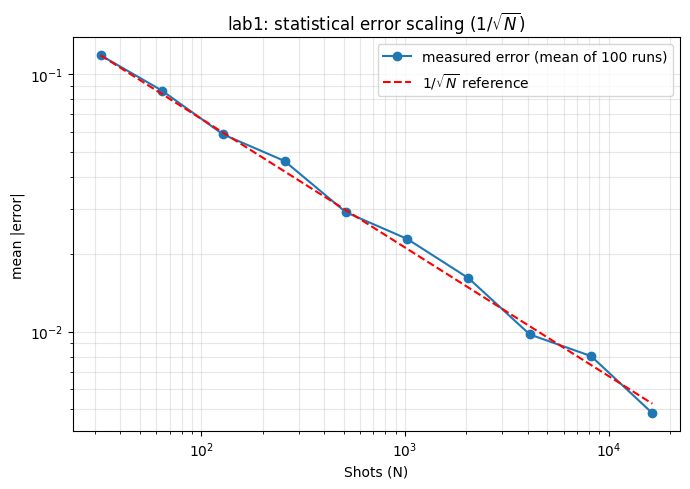

In [14]:
# 1/sqrt(N) 기준선과 함께 그리기
ref = mean_err[0] * (shot_scan[0] / np.array(shot_scan)) ** 0.5
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(shot_scan, mean_err, "o-", label=f"measured error (mean of {Repeat} runs)")
ax.loglog(shot_scan, ref, "r--", label=r"$1/\sqrt{N}$ reference")
ax.set_xlabel("Shots (N)")
ax.set_ylabel("mean |error|")
ax.set_title(r"lab1: statistical error scaling ($1/\sqrt{N}$)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()

plt.show()